# 04 — Evaluation

Compare all fine-tuned models and LLM baselines on the **Russian annotated test set**.

**Sections**
1. Configuration
2. Run evaluation (inference on all models)
3. Results table
4. F1 comparison — weighted vs unweighted
5. Effect of K value
6. Effect of embedding space (raw vs PCA)
7. Metric heatmap
8. Confusion matrices
9. Bootstrap confidence intervals

In [1]:
import sys, os
if os.getcwd().endswith('notebooks'):
    os.chdir('..')

import yaml
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from src.evaluation import evaluate_all, discover_models, compute_metrics, bootstrap_ci, get_confusion_matrix

sns.set_theme(style="whitegrid")

c:\Users\Alexandre\miniconda3\envs\faiss2\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 1. Configuration

In [2]:
CONFIG_PATH = "configs/datasets.yaml"

with open(CONFIG_PATH) as f:
    cfg = yaml.safe_load(f)

PREPROCESSED_ROOT = cfg["preprocessing"]["output_root"]
TRAINING_ROOT     = cfg["training"]["output_root"]
EVAL_ROOT         = cfg["evaluation"]["output_root"]
MAX_LENGTH        = cfg["training"]["max_length"]

# Russian annotated test set — the only evaluation target
RUSSIAN_TEST_CSV  = os.path.join(PREPROCESSED_ROOT, "russian", "full.csv")
EXPERIMENT_NAME   = "main"
OUTPUT_DIR        = os.path.join(EVAL_ROOT, EXPERIMENT_NAME)

RUN_EVAL = True  # set True to run inference on all models

print("Russian test CSV:", RUSSIAN_TEST_CSV)
print("Training root   :", TRAINING_ROOT)
print("Output dir      :", OUTPUT_DIR)

Russian test CSV: outputs/1_preprocessed\russian\full.csv
Training root   : outputs/3_training
Output dir      : outputs/4_evaluation\main


## 2. Run Evaluation

Discovers all fine-tuned models from `outputs/3_training/`, runs inference on the Russian test set, and saves results.  
Set `RUN_EVAL = True` the first time. Subsequent runs load the cached `results.csv`.

In [3]:
results_path = os.path.join(OUTPUT_DIR, "results.csv")

# if RUN_EVAL or not os.path.exists(results_path):
if RUN_EVAL:
    results = evaluate_all(
        test_csv=RUSSIAN_TEST_CSV,
        training_root=TRAINING_ROOT,
        output_dir=OUTPUT_DIR,
        max_length=MAX_LENGTH,
        bootstrap=True,
        n_bootstrap=1000,
        base_models=cfg["training"]["models"],
        specialists=False
    )
else:
    print("Loading cached results from", results_path)
    results = pd.read_csv(results_path)

print(f"{len(results)} models evaluated")
print("Columns:", results.columns.tolist())

Loading weights: 100%|██████████| 136/136 [00:00<00:00, 4176.16it/s]
[transformers] ModernBertForSequenceClassification LOAD REPORT from: answerdotai/ModernBERT-base
Key               | Status     | 
------------------+------------+-
decoder.bias      | UNEXPECTED | 
classifier.bias   | MISSING    | 
classifier.weight | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
Loading weights: 100%|██████████| 393/393 [00:00<00:00, 32697.15it/s]


16 models evaluated
Columns: ['run_name', 'model_slug', 'train_dataset', 'density_tag', 'weighted', 'space', 'k', 'accuracy', 'balanced_accuracy', 'precision', 'recall', 'f1', 'auc_roc', 'f1_ci_lower', 'f1_ci_upper']


## 3. Results Table

In [4]:
display_cols = ["model_slug", "run_name", "train_dataset", "density_tag", "weighted", "space", "k",
                "f1", "balanced_accuracy", "accuracy", "auc_roc"]
display_cols = [c for c in display_cols if c in results.columns]

display(
    results[display_cols]
    .sort_values("f1", ascending=False)
    .style.format({c: "{:.4f}" for c in ["f1", "balanced_accuracy", "accuracy", "auc_roc"] if c in display_cols})
    .background_gradient(subset=["f1"], cmap="YlGn")
)

,model_slug,run_name,train_dataset,density_tag,weighted,space,k,f1,balanced_accuracy,accuracy,auc_roc
0,tomh_toxigen_roberta,tomh_toxigen_roberta__toxigen__density_k5_ratio,toxigen,density_k5_ratio,True,raw,5.000000,0.5755,0.7862,0.7319,0.8377
1,tomh_toxigen_roberta,tomh_toxigen_roberta__toxigen__density_k100_ratio,toxigen,density_k100_ratio,True,raw,100.000000,0.5667,0.7708,0.7390,0.8340
2,answerdotai_ModernBERT-base,answerdotai_ModernBERT-base__toxigen__density_pca_k100_ratio,toxigen,density_pca_k100_ratio,True,pca,100.000000,0.5633,0.7824,0.7088,0.8394
3,answerdotai_ModernBERT-base,answerdotai_ModernBERT-base__toxigen__density_pca_k5_ratio,toxigen,density_pca_k5_ratio,True,pca,5.000000,0.5550,0.7699,0.7118,0.8350
4,tomh_toxigen_roberta,tomh_toxigen_roberta__toxigen__density_k1000_ratio,toxigen,density_k1000_ratio,True,raw,1000.000000,0.5531,0.7731,0.6998,0.8301
5,answerdotai_ModernBERT-base,answerdotai_ModernBERT-base__toxigen__density_k1000_ratio,toxigen,density_k1000_ratio,True,raw,1000.000000,0.5511,0.7723,0.6958,0.8346
6,answerdotai_ModernBERT-base,answerdotai_ModernBERT-base__toxigen__no_density,toxigen,no_density,False,nan,nan,0.5468,0.7719,0.6837,0.8464
7,answerdotai_ModernBERT-base,answerdotai_ModernBERT-base__toxigen__density_k5_ratio,toxigen,density_k5_ratio,True,raw,5.000000,0.5466,0.7569,0.7169,0.8322
8,tomh_toxigen_roberta,tomh_toxigen_roberta__toxigen__no_density,toxigen,no_density,False,nan,nan,0.5407,0.7641,0.6827,0.8426
9,tomh_toxigen_roberta,tomh_toxigen_roberta__base_model,base_model,no_density,False,nan,nan,0.5392,0.7651,0.6757,0.8291


## 4. F1 Comparison — Density-Weighted vs Unweighted

C:\Users\Alexandre\AppData\Local\Temp\ipykernel_10600\2660701456.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_f1, x="weight_label", y="f1", ax=ax, palette=["#e74c3c", "#95a5a6"])


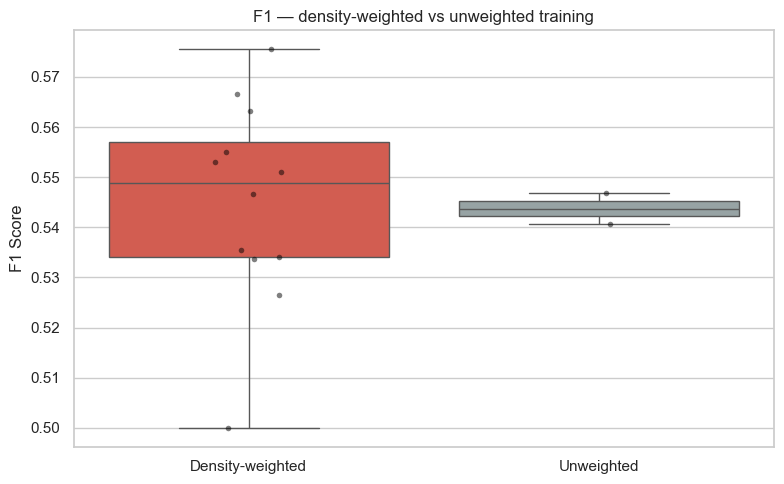

In [7]:
df_f1 = results.dropna(subset=["f1", "weighted"]).copy()
# Filter out the base model from the comparison
df_f1 = df_f1[df_f1["train_dataset"] != "base_model"]
df_f1["weight_label"] = df_f1["weighted"].map({True: "Density-weighted", False: "Unweighted"})

fig, ax = plt.subplots(figsize=(8, 5))
sns.boxplot(data=df_f1, x="weight_label", y="f1", ax=ax, palette=["#e74c3c", "#95a5a6"])
sns.stripplot(data=df_f1, x="weight_label", y="f1", ax=ax, color="black", alpha=0.5, size=4)
ax.set_xlabel("")
ax.set_ylabel("F1 Score")
ax.set_title("F1 — density-weighted vs unweighted training")
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "plots", "weighted_vs_unweighted.png"), dpi=150)
plt.show()


## 5. Effect of K Value

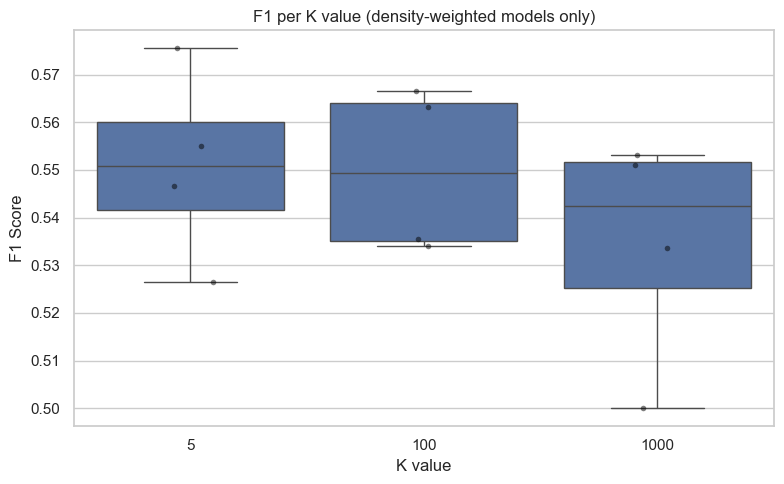

In [6]:
df_k = results.dropna(subset=["k", "f1"]).copy()
df_k["k"] = df_k["k"].astype(int)

if not df_k.empty:
    fig, ax = plt.subplots(figsize=(8, 5))
    sns.boxplot(data=df_k, x="k", y="f1", ax=ax)
    sns.stripplot(data=df_k, x="k", y="f1", ax=ax, color="black", alpha=0.5, size=4)
    ax.set_xlabel("K value")
    ax.set_ylabel("F1 Score")
    ax.set_title("F1 per K value (density-weighted models only)")
    plt.tight_layout()
    plt.savefig(os.path.join(OUTPUT_DIR, "plots", "f1_by_k.png"), dpi=150)
    plt.show()
else:
    print("No density-weighted models found yet.")

## 6. Effect of Embedding Space (Raw vs PCA)

C:\Users\Alexandre\AppData\Local\Temp\ipykernel_10600\1868115419.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_space, x="space", y="f1", ax=axes[0], palette=["#3498db", "#e67e22"])


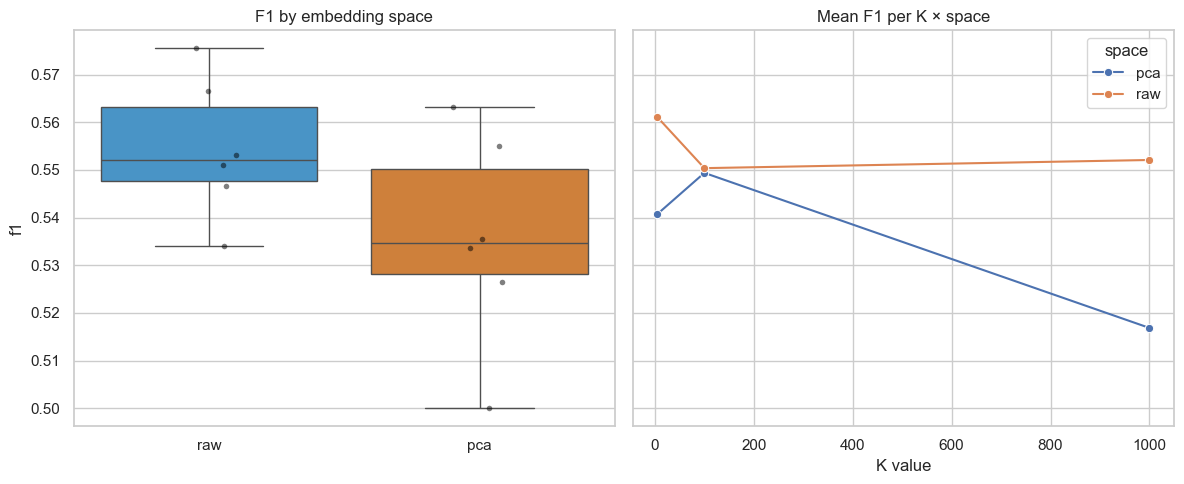

In [8]:
df_space = results.dropna(subset=["space", "f1"]).copy()

if not df_space.empty:
    fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharey=True)

    # Box per space
    sns.boxplot(data=df_space, x="space", y="f1", ax=axes[0], palette=["#3498db", "#e67e22"])
    sns.stripplot(data=df_space, x="space", y="f1", ax=axes[0], color="black", alpha=0.5, size=4)
    axes[0].set_title("F1 by embedding space")
    axes[0].set_xlabel("")

    # Line per K, grouped by space
    df_grouped = df_space.groupby(["k", "space"])["f1"].mean().reset_index()
    sns.lineplot(data=df_grouped, x="k", y="f1", hue="space", marker="o", ax=axes[1])
    axes[1].set_title("Mean F1 per K × space")
    axes[1].set_xlabel("K value")

    plt.tight_layout()
    plt.savefig(os.path.join(OUTPUT_DIR, "plots", "f1_space_vs_k.png"), dpi=150)
    plt.show()
else:
    print("No density-weighted models found yet.")

## 7. Metric Heatmap

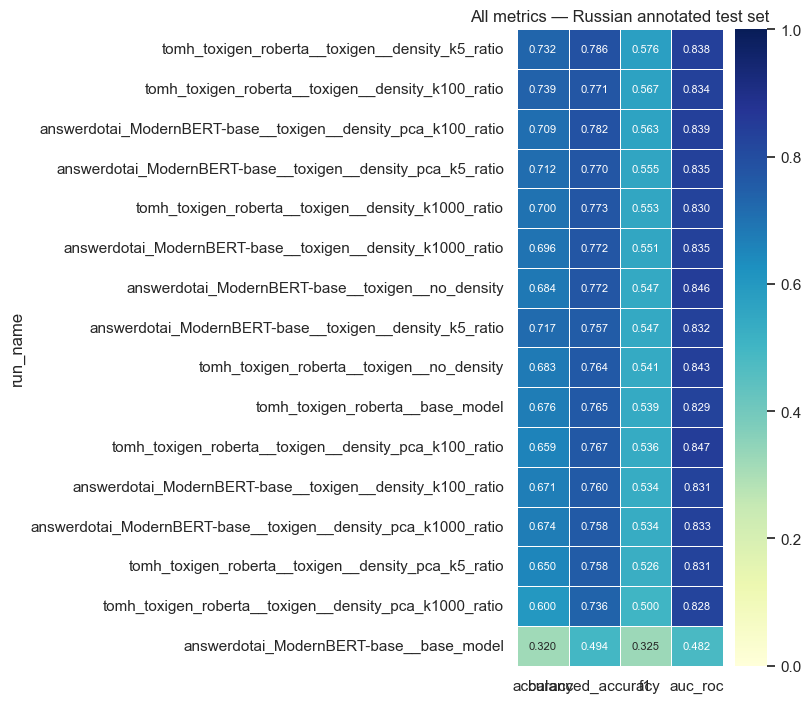

In [9]:
metric_cols = [c for c in ["accuracy", "balanced_accuracy", "f1", "auc_roc"] if c in results.columns]
heatmap_df = (
    results.dropna(subset=["f1"])
    .set_index("run_name")[metric_cols]
    .astype(float)
    .sort_values("f1", ascending=False)
)

fig, ax = plt.subplots(figsize=(8, max(4, len(heatmap_df) * 0.45)))
sns.heatmap(heatmap_df, annot=True, fmt=".3f", cmap="YlGnBu",
            vmin=0, vmax=1, linewidths=0.5, annot_kws={"size": 8}, ax=ax)
ax.set_title("All metrics — Russian annotated test set")
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "plots", "metrics_heatmap.png"), dpi=150)
plt.show()

## 8. Confusion Matrices

Saved per-model PNGs are in `outputs/4_evaluation/main/confusion/`.  
Display the top-3 models here.

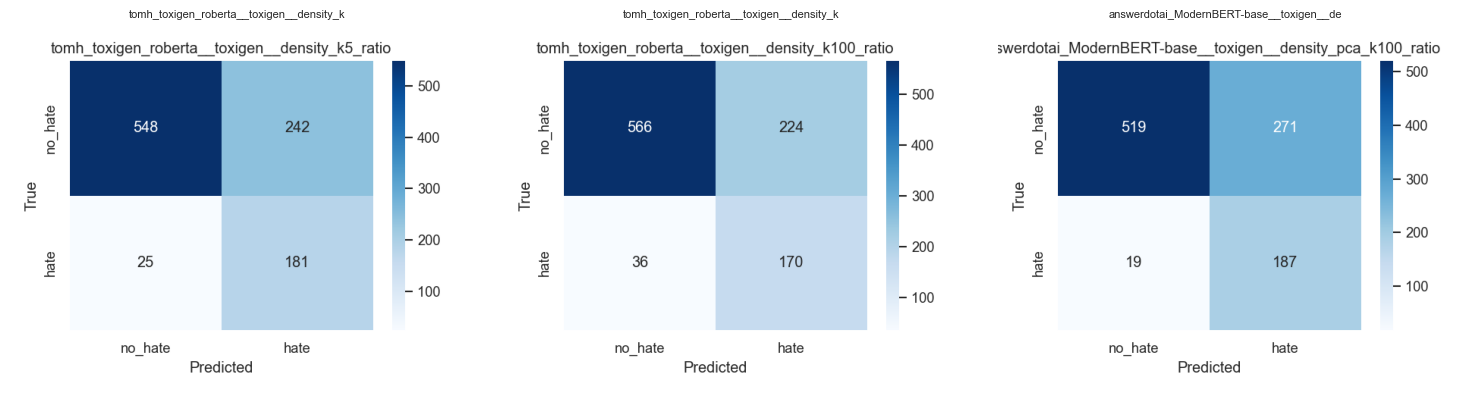

In [10]:
from PIL import Image
import glob

confusion_dir = os.path.join(OUTPUT_DIR, "confusion")
top3 = results.dropna(subset=["f1"]).head(3)["run_name"].tolist()

fig, axes = plt.subplots(1, len(top3), figsize=(5 * len(top3), 4))
if len(top3) == 1:
    axes = [axes]

for ax, run_name in zip(axes, top3):
    safe = run_name.replace("/", "_").replace("\\", "_")
    img_path = os.path.join(confusion_dir, f"{safe}.png")
    if os.path.exists(img_path):
        ax.imshow(Image.open(img_path))
        ax.axis("off")
        ax.set_title(run_name[:40], fontsize=8)
    else:
        ax.set_title(f"{run_name[:30]} — not found")
        ax.axis("off")

plt.tight_layout()
plt.show()

## 9. Bootstrap Confidence Intervals

F1 CIs for all models, sorted by point estimate.

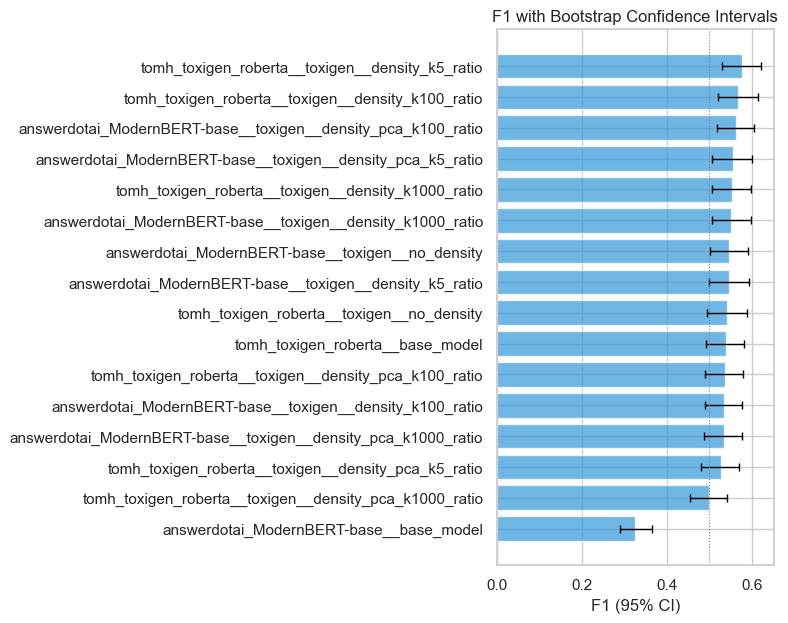

In [11]:
ci_cols = ["run_name", "f1", "f1_ci_lower", "f1_ci_upper"]
ci_cols = [c for c in ci_cols if c in results.columns]

if "f1_ci_lower" in results.columns:
    df_ci = results[ci_cols].dropna().sort_values("f1", ascending=True)

    fig, ax = plt.subplots(figsize=(8, max(4, len(df_ci) * 0.4)))
    ax.barh(df_ci["run_name"], df_ci["f1"], color="#3498db", alpha=0.7)
    ax.errorbar(
        df_ci["f1"], df_ci["run_name"],
        xerr=[df_ci["f1"] - df_ci["f1_ci_lower"], df_ci["f1_ci_upper"] - df_ci["f1"]],
        fmt="none", color="black", capsize=3, linewidth=1,
    )
    ax.set_xlabel("F1 (95% CI)")
    ax.set_title("F1 with Bootstrap Confidence Intervals")
    ax.axvline(0.5, color="grey", linestyle=":", linewidth=0.8)
    plt.tight_layout()
    plt.savefig(os.path.join(OUTPUT_DIR, "plots", "f1_bootstrap_ci.png"), dpi=150)
    plt.show()
else:
    print("Bootstrap CIs not computed — re-run with bootstrap=True.")

## 10. Ensemble Evaluation

Evaluate the specialist ensemble on the Russian test set.

**How it works**
- One specialist model per ToxiGen group was trained in **notebook 03_01**.
- Each specialist scores every Russian test sample independently.
- Votes are combined using group-level density weights:  
  `w_g = mean(density_k{K}_russian)` for all ToxiGen samples in group g.  
  Weights are shift-and-normalised so the least-similar group gets 0 and differences are amplified.
- The group with the highest average Russian-HS affinity gets the highest voting weight.

**Set `ENSEMBLE_K` and `ENSEMBLE_SPACE` to match the best general model found in Section 3.**


In [12]:
import json as _json
import glob
from src.evaluation.ensemble import evaluate_ensemble, compute_group_weights, normalise_weights

# Densities CSV (ToxiGen, embedding model space)
_emb_cfg        = cfg["embedding"]
_emb_model_slug = _emb_cfg["models"][0].replace("/", "_")
TOXIGEN_DENSITIES_CSV = os.path.join(
    _emb_cfg["output_root"], "toxigen", _emb_model_slug, "densities.csv"
)

# --- Parameters (align with best general model from Section 3) ---
ENSEMBLE_K     = 100      # best K from general model leaderboard
ENSEMBLE_SPACE = "pca"    # "raw" or "pca"
VOTING         = "weighted_average"  # "weighted_average" or "majority"
MODEL_SLUG     = None     # None = all specialists

# --- Normalisation Parameters ---
NORM_METHOD    = "linear" # "softmax" (best for log-densities) or "linear"
NORM_TEMP      = 5.0       # Higher = more uniform weights; Lower = more aggressive

RUN_ENSEMBLE = True  # set True to run (loads all specialist models — slow)

print("Toxigen densities CSV:", TOXIGEN_DENSITIES_CSV)
print("Ensemble K           :", ENSEMBLE_K)
print("Ensemble space       :", ENSEMBLE_SPACE)
print("Voting               :", VOTING)
print(f"Normalisation        : {NORM_METHOD} (T={NORM_TEMP})")

Toxigen densities CSV: outputs/2_embeddings\toxigen\sentence-transformers_all-mpnet-base-v2\densities.csv
Ensemble K           : 100
Ensemble space       : pca
Voting               : weighted_average
Normalisation        : linear (T=5.0)


### 10.1 Preview ensemble voting weights

,raw_log_density,voting_weight
group,,
jewish,191.9560,0.2707
middle_east,189.1054,0.1531
muslim,186.8445,0.0974
chinese,185.2544,0.0709
women,185.1546,0.0695
latino,184.9004,0.0660
mexican,184.6245,0.0625
native_american,184.0422,0.0556
lgbtq,183.4429,0.0493


C:\Users\Alexandre\AppData\Local\Temp\ipykernel_10600\1204768973.py:24: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(weights_df.index, rotation=45, ha="right")


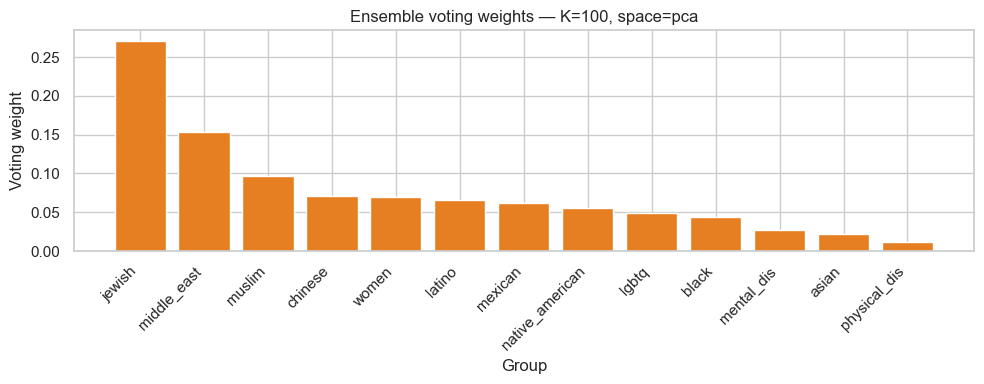

In [13]:
raw_w  = compute_group_weights(TOXIGEN_DENSITIES_CSV, k=ENSEMBLE_K, space=ENSEMBLE_SPACE)
norm_w = normalise_weights(raw_w)

weights_df = (
    pd.DataFrame([
        {"group": g, "raw_log_density": raw_w[g], "voting_weight": norm_w[g]}
        for g in sorted(raw_w)
    ])
    .set_index("group")
    .sort_values("voting_weight", ascending=False)
)

display(
    weights_df.style
    .format("{:.4f}")
    .background_gradient(subset=["voting_weight"], cmap="YlOrRd")
)

fig, ax = plt.subplots(figsize=(10, 4))
ax.bar(weights_df.index, weights_df["voting_weight"], color="#e67e22")
ax.set_xlabel("Group")
ax.set_ylabel("Voting weight")
ax.set_title(f"Ensemble voting weights — K={ENSEMBLE_K}, space={ENSEMBLE_SPACE}")
ax.set_xticklabels(weights_df.index, rotation=45, ha="right")
plt.tight_layout()
plt.show()


### 10.2 Run ensemble evaluation

In [14]:
if RUN_ENSEMBLE:
    ensemble_metrics = evaluate_ensemble(
        test_csv              = RUSSIAN_TEST_CSV,
        toxigen_densities_csv = TOXIGEN_DENSITIES_CSV,
        training_root         = TRAINING_ROOT,
        output_dir            = OUTPUT_DIR,
        k                     = ENSEMBLE_K,
        space                 = ENSEMBLE_SPACE,
        voting                = VOTING,
        model_slug            = MODEL_SLUG,
        batch_size            = 32,
        max_length            = MAX_LENGTH,
        bootstrap             = True,
        n_bootstrap           = 1000,
        norm_method=NORM_METHOD,
        norm_temperature=NORM_TEMP
    )
else:
    slug_tag = f"_{MODEL_SLUG}" if MODEL_SLUG else ""
    pattern = os.path.join(
        OUTPUT_DIR,
        f"ensemble{slug_tag}_{VOTING}_{ENSEMBLE_SPACE}_k{ENSEMBLE_K}_results.json"
    )
    matches = glob.glob(pattern)
    if matches:
        with open(matches[0]) as f:
            ensemble_metrics = _json.load(f)
        print(f"Loaded: {matches[0]}")
    else:
        print(f"[MISSING] No cached results matching: {pattern}")
        print("Set RUN_ENSEMBLE = True to run the evaluation.")
        ensemble_metrics = None


Loading weights: 100%|██████████| 138/138 [00:00<00:00, 225.35it/s]


### 10.3 Ensemble results vs. general models

In [15]:
if ensemble_metrics:
    ens_row = {
        "run_name"         : ensemble_metrics["run_name"],
        "model_slug"       : ensemble_metrics.get("model_slug") or "all",
        "train_dataset"    : "ensemble",
        "density_tag"      : f"{ENSEMBLE_SPACE}_k{ENSEMBLE_K}",
        "weighted"         : True,
        "space"            : ensemble_metrics["space"],
        "k"                : ensemble_metrics["k"],
        "f1"               : ensemble_metrics["f1"],
        "balanced_accuracy": ensemble_metrics["balanced_accuracy"],
        "accuracy"         : ensemble_metrics["accuracy"],
        "auc_roc"          : ensemble_metrics["auc_roc"],
    }
    if "f1_ci_lower" in ensemble_metrics:
        ens_row["f1_ci_lower"] = ensemble_metrics["f1_ci_lower"]
        ens_row["f1_ci_upper"] = ensemble_metrics["f1_ci_upper"]

    ens_df = (
        pd.concat([results, pd.DataFrame([ens_row])], ignore_index=True)
        .sort_values("f1", ascending=False)
    )

    display_cols = ["run_name", "train_dataset", "weighted", "space", "k",
                    "f1", "balanced_accuracy", "auc_roc"]
    display(
        ens_df[display_cols]
        .style
        .format({"f1": "{:.4f}", "balanced_accuracy": "{:.4f}",
                 "auc_roc": "{:.4f}", "k": "{:.0f}"}, na_rep="—")
        .background_gradient(subset=["f1"], cmap="YlGn")
    )

    print(f"\nEnsemble F1     : {ensemble_metrics['f1']:.4f}")
    print(f"Ensemble BalAcc : {ensemble_metrics['balanced_accuracy']:.4f}")
    print(f"Ensemble AUC-ROC: {ensemble_metrics['auc_roc']:.4f}")
    if "f1_ci_lower" in ensemble_metrics:
        print(f"95% CI F1       : [{ensemble_metrics['f1_ci_lower']:.4f}, {ensemble_metrics['f1_ci_upper']:.4f}]")
    print(f"Groups used     : {ensemble_metrics['n_groups']}")
    print(f"Voting weights  :")
    for g, w in sorted(ensemble_metrics['weights'].items(), key=lambda x: -x[1]):
        print(f"  {g:20s}: {w:.4f}")
else:
    print("No ensemble results yet — run Section 10.2 first.")


,run_name,train_dataset,weighted,space,k,f1,balanced_accuracy,auc_roc
0,tomh_toxigen_roberta__toxigen__density_k5_ratio,toxigen,True,raw,5,0.5755,0.7862,0.8377
1,tomh_toxigen_roberta__toxigen__density_k100_ratio,toxigen,True,raw,100,0.5667,0.7708,0.8340
2,answerdotai_ModernBERT-base__toxigen__density_pca_k100_ratio,toxigen,True,pca,100,0.5633,0.7824,0.8394
3,answerdotai_ModernBERT-base__toxigen__density_pca_k5_ratio,toxigen,True,pca,5,0.5550,0.7699,0.8350
4,tomh_toxigen_roberta__toxigen__density_k1000_ratio,toxigen,True,raw,1000,0.5531,0.7731,0.8301
5,answerdotai_ModernBERT-base__toxigen__density_k1000_ratio,toxigen,True,raw,1000,0.5511,0.7723,0.8346
6,answerdotai_ModernBERT-base__toxigen__no_density,toxigen,False,—,—,0.5468,0.7719,0.8464
7,answerdotai_ModernBERT-base__toxigen__density_k5_ratio,toxigen,True,raw,5,0.5466,0.7569,0.8322
16,ensemble_weighted_average_pca_k100,ensemble,True,pca,100,0.5446,0.7628,0.8289
8,tomh_toxigen_roberta__toxigen__no_density,toxigen,False,—,—,0.5407,0.7641,0.8426



Ensemble F1     : 0.5446
Ensemble BalAcc : 0.7628
Ensemble AUC-ROC: 0.8289
95% CI F1       : [0.4953, 0.5901]
Groups used     : 13
Voting weights  :
  jewish              : 0.1412
  middle_east         : 0.1176
  muslim              : 0.0989
  chinese             : 0.0857
  women               : 0.0849
  latino              : 0.0828
  mexican             : 0.0805
  native_american     : 0.0757
  lgbtq               : 0.0708
  black               : 0.0658
  mental_dis          : 0.0467
  asian               : 0.0363
  physical_dis        : 0.0128


In [16]:
# --- Define variants to compare ---
ENSEMBLE_CONFIGS = [
    {"voting": "weighted_average", "norm": "softmax", "temp": 5.0, "label": "Ensemble (Weighted + Softmax)"},
    {"voting": "weighted_average", "norm": "linear",  "temp": 5.0, "label": "Ensemble (Weighted + Linear)"},
    {"voting": "majority",         "norm": "softmax", "temp": 5.0, "label": "Ensemble (Majority Vote)"},
]

all_ensemble_metrics = []

if RUN_ENSEMBLE:
    for e_cfg in ENSEMBLE_CONFIGS:
        print(f"\n>>> Running: {e_cfg['label']}...")
        m = evaluate_ensemble(
            test_csv              = RUSSIAN_TEST_CSV,
            toxigen_densities_csv = TOXIGEN_DENSITIES_CSV,
            training_root         = TRAINING_ROOT,
            output_dir            = OUTPUT_DIR,
            k                     = ENSEMBLE_K,
            space                 = ENSEMBLE_SPACE,
            voting                = e_cfg["voting"],
            model_slug            = MODEL_SLUG,
            batch_size            = 32,
            max_length            = MAX_LENGTH,
            bootstrap             = True,
            n_bootstrap           = 1000,
            norm_method           = e_cfg["norm"],
            norm_temperature      = e_cfg["temp"]
        )
        m["display_label"] = e_cfg["label"]
        all_ensemble_metrics.append(m)
else:
    # Try to load the latest run from the default filename
    slug_tag = f"_{MODEL_SLUG}" if MODEL_SLUG else ""
    # Since they share a filename, this just loads whatever was run last
    pattern = os.path.join(OUTPUT_DIR, f"ensemble{slug_tag}_{VOTING}_{ENSEMBLE_SPACE}_k{ENSEMBLE_K}_results.json")
    matches = glob.glob(pattern)
    if matches:
        with open(matches[0]) as f:
            m = _json.load(f)
            m["display_label"] = "Ensemble (Cached)"
            all_ensemble_metrics.append(m)
            print(f"Loaded cached: {matches[0]}")

# --- Display Comparison Table ---
if all_ensemble_metrics:
    ens_rows = []
    for m in all_ensemble_metrics:
        row = {
            "run_name"         : m["display_label"],
            "model_slug"       : m.get("model_slug") or "all",
            "train_dataset"    : "ensemble",
            "voting"           : m["voting"],
            "norm_method"      : m.get("norm_method", "N/A") if m["voting"] != "majority" else "N/A",
            "f1"               : m["f1"],
            "balanced_accuracy": m["balanced_accuracy"],
            "auc_roc"          : m["auc_roc"],
        }
        if "f1_ci_lower" in m:
            row["f1_ci_lower"] = m["f1_ci_lower"]
            row["f1_ci_upper"] = m["f1_ci_upper"]
        ens_rows.append(row)

    # Combine with main results
    ens_df = pd.concat([results, pd.DataFrame(ens_rows)], ignore_index=True)
    
    display_cols = ["run_name", "train_dataset", "voting", "norm_method", "f1", "balanced_accuracy", "auc_roc"]
    display_cols = [c for c in display_cols if c in ens_df.columns]
    
    display(
        ens_df[display_cols]
        .sort_values("f1", ascending=False)
        .style
        .format({"f1": "{:.4f}", "balanced_accuracy": "{:.4f}", "auc_roc": "{:.4f}"}, na_rep="—")
        .background_gradient(subset=["f1"], cmap="YlGn")
    )
else:
    print("No ensemble results. Set RUN_ENSEMBLE = True to generate comparison.")



>>> Running: Ensemble (Weighted + Softmax)...


Loading weights: 100%|██████████| 138/138 [00:00<00:00, 9457.74it/s]



>>> Running: Ensemble (Weighted + Linear)...


Loading weights: 100%|██████████| 138/138 [00:00<00:00, 10173.55it/s]



>>> Running: Ensemble (Majority Vote)...


Loading weights: 100%|██████████| 138/138 [00:00<00:00, 9298.81it/s]


,run_name,train_dataset,voting,norm_method,f1,balanced_accuracy,auc_roc
0,tomh_toxigen_roberta__toxigen__density_k5_ratio,toxigen,—,—,0.5755,0.7862,0.8377
1,tomh_toxigen_roberta__toxigen__density_k100_ratio,toxigen,—,—,0.5667,0.7708,0.8340
2,answerdotai_ModernBERT-base__toxigen__density_pca_k100_ratio,toxigen,—,—,0.5633,0.7824,0.8394
3,answerdotai_ModernBERT-base__toxigen__density_pca_k5_ratio,toxigen,—,—,0.5550,0.7699,0.8350
4,tomh_toxigen_roberta__toxigen__density_k1000_ratio,toxigen,—,—,0.5531,0.7731,0.8301
16,Ensemble (Weighted + Softmax),ensemble,weighted_average,softmax,0.5529,0.7714,0.8312
5,answerdotai_ModernBERT-base__toxigen__density_k1000_ratio,toxigen,—,—,0.5511,0.7723,0.8346
6,answerdotai_ModernBERT-base__toxigen__no_density,toxigen,—,—,0.5468,0.7719,0.8464
7,answerdotai_ModernBERT-base__toxigen__density_k5_ratio,toxigen,—,—,0.5466,0.7569,0.8322
18,Ensemble (Majority Vote),ensemble,majority,N/A,0.5452,0.7640,0.8011
